### **Handling Imbalanced datasets**

Imbalanced data occurs when one class has far more samples than others, causing models to favour the majority class and perform poorly on the minority class. This often results in misleading accuracy, especially in critical applications like fraud detection or medical diagnosis.

1. ML models tend to get biased toward the majority class and predict it more frequently.

2. Minority class instances may be treated as noise, causing the model to overlook them.

3. Accuracy becomes misleading because the model performs well only on the dominant class.

4. Skewed decision boundaries lead to poor generalisation and weak performance on minority class predictions.

The common approach to class imbalance is resampling. These can entail oversampling the majority class, undersampling the minority class, or a combination of both.

1. Random oversampling

2. Random undersampling

3. Oversampling with SMOTE

4. Oversampling with ADASYN

5. Undersampling with Tomek Link

6. Oversampling with SMOTE, then undersample with TOMEK Link (SMOTE-Tomek)

**Using Imbalance-learn**

We will use the imbalanced-learn package in python to solve our imbalanced class problem. It is an open-sourced library relying on scikit-learn and provides tools when dealing with classification with imbalanced classes.

    pip install -U imbalanced-learn

In [2]:
pip install -U imbalanced-learn

  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/c7/b5/56f1ceb568676c0231d12b2fed17ebfd606dd1f627e7372aaed5dd56bd97/imbalanced_learn-0.14.1-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<0.2,>=0.1.5 from https://files.pythonhosted.org/packages/53/60/08cb1b41563a0a8f26a72b8c5d1726986ab535fee67aa95541b2a2cc1dfa/sklearn_compat-0.1.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ------ --------------------------------- 41.0/235.4 kB 2.0 MB/s eta 0:00:01
   -------------------------------------- - 225.3/235.4 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 235.4/235.4 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Convert the dictionary to a pandas dataframe
import pandas as pd
crime_df = pd.concat([pd.DataFrame(us_crime['data'], columns = [f'data_{i}' for i in range(us_crime.data.shape[1])]),
           pd.DataFrame(us_crime['target'], columns = ['target'])], axis = 1)

# Split data into train test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(crime_df.drop('target', axis = 1), 
                                                    crime_df['target'], 
                                                    test_size = 0.4, 
                                                    random_state = 42)

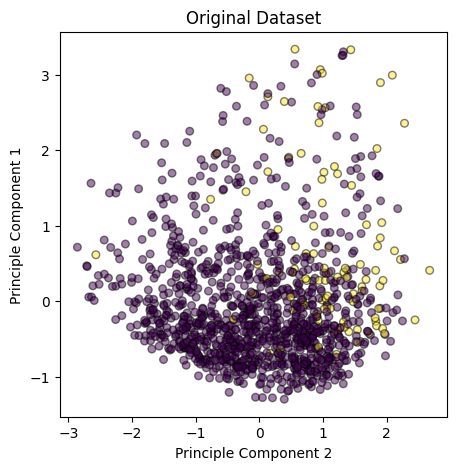

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale the dataset on both train and test sets.
# Note that we fit MinMaxScaler on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Perform PCA Decomposition on both train and test sets
# Note that we fit PCA on X_train only, not on the entire dataset.
# This prevents data leakage from test set to train set.
pca = PCA(n_components=2)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Function for plotting dataset 
def plot_data(X,y,ax,title):
    ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5, s = 30, edgecolor=(0,0,0,0.5))
    ax.set_ylabel('Principle Component 1')
    ax.set_xlabel('Principle Component 2')
    if title is not None:
        ax.set_title(title)

# Plot dataset
fig,ax = plt.subplots(figsize=(5, 5))
plot_data(X_train_pca, y_train, ax, title='Original Dataset')

**Strategy 1. Random Oversampling**

Random oversampling duplicates existing examples from the minority class with replacement. Each data point in the minority class has an equal probability of being duplicated.

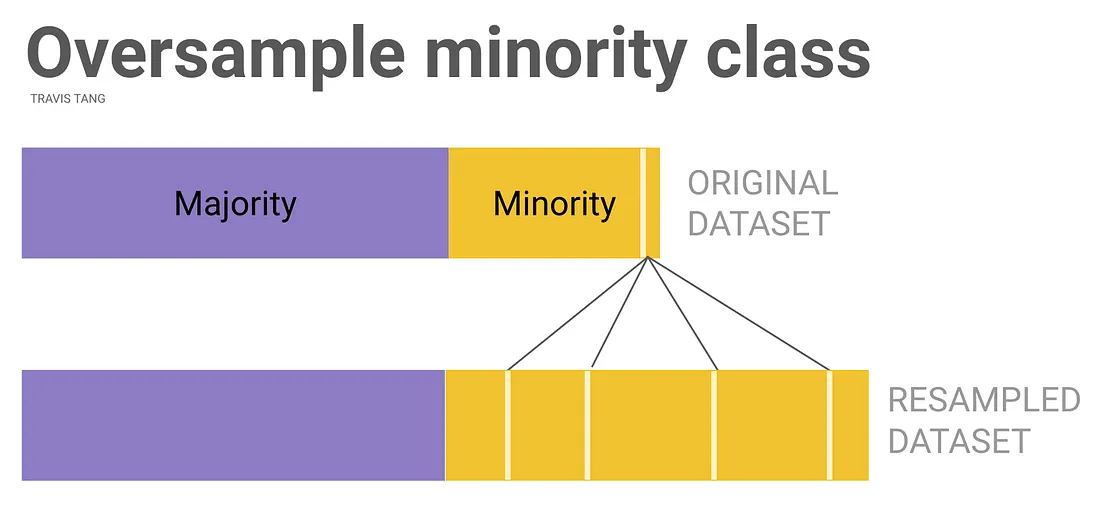

In [11]:
from imblearn.over_sampling import RandomOverSampler

# Perform random oversampling
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(X_train_pca, y_train)

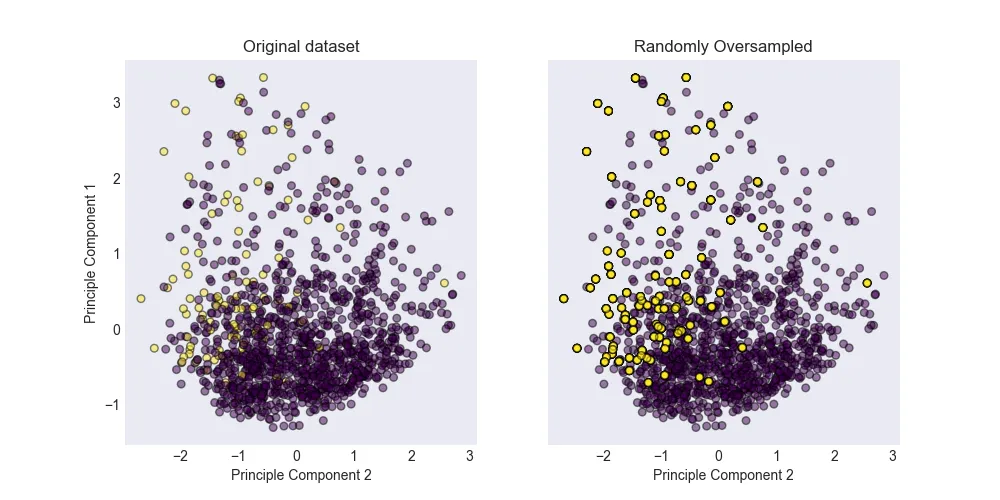

**Strategy 2. Random Undersampling**

Conversely, random undersampling removes existing samples from the majority class. Each data point in the majority class has an equal chance of being removed.

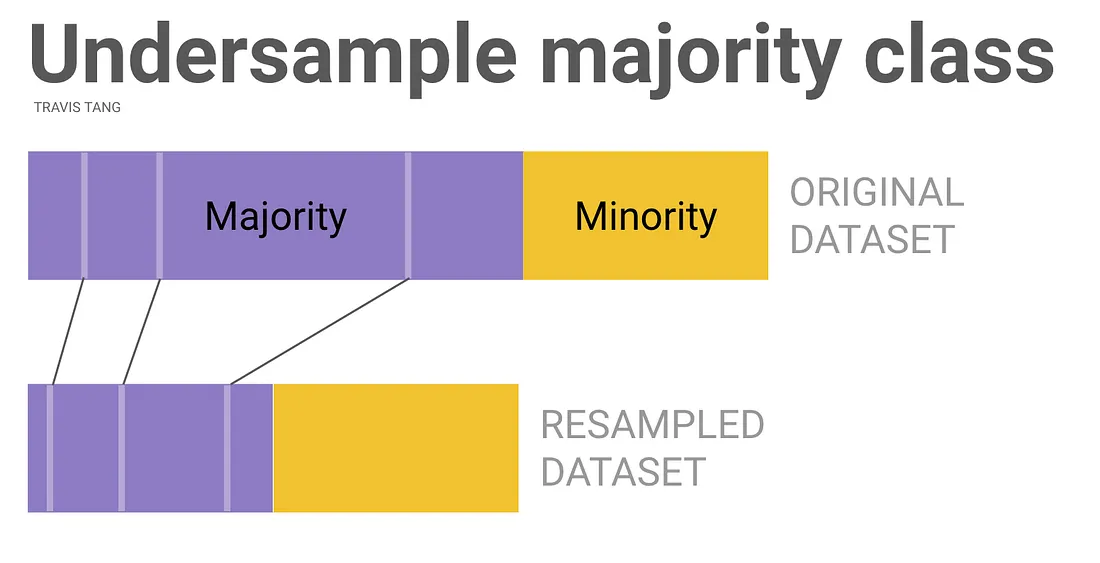

In [13]:
from imblearn.under_sampling import RandomUnderSampler

# Perform random sampling
rus = RandomUnderSampler(random_state=0)
X_train_rus, y_train_rus = rus.fit_resample(X_train_pca, y_train)

**Applying machine learning to under- and over-sampled sets**

Let’s compare the performance of a classification machine learning model (SVM model) trained on three datasets above (unmodified, under- dataset, and over-sampled dataset)

Here, we train three Support Vector Machine Classifiers (SVC) on three datasets:

Original data

Randomly over-sampled data

randomly under-sampled data

In [14]:
from sklearn.svm import SVC

# Train SVC on original data
clf_ros = SVC(kernel='linear',probability=True)
clf_ros.fit(X_train_pca, y_train)

# Train SVC on randomly oversampled data
clf_ros = SVC(kernel='linear',probability=True)
clf_ros.fit(X_train_ros, y_train_ros)

# Train SVC on randomly undersampled data
clf_rus = SVC(kernel='linear',probability=True)
clf_rus.fit(X_train_rus, y_train_rus)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


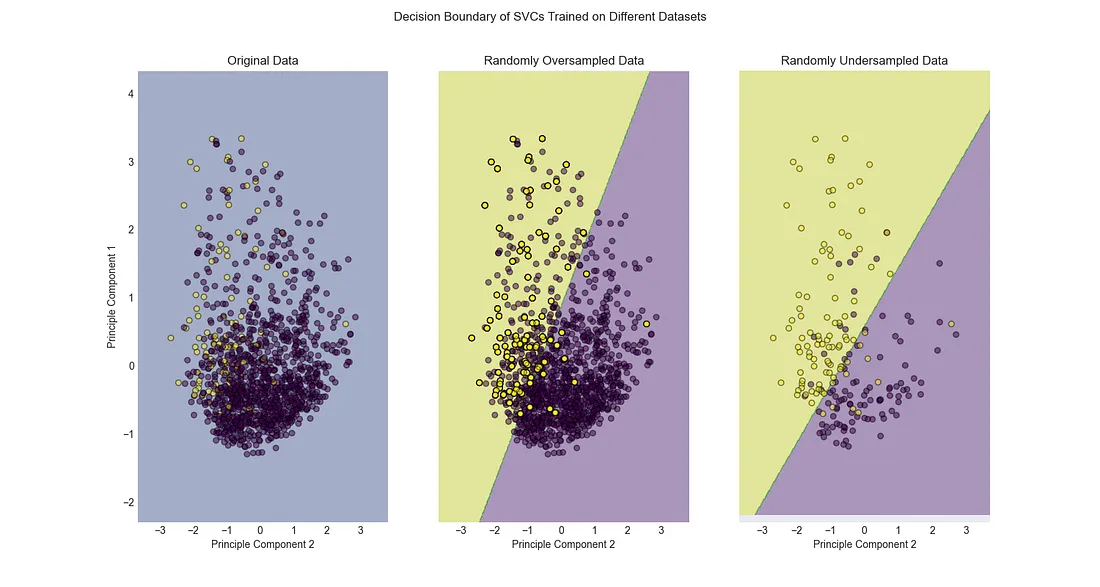

The graphs above summarize what the algorithms have learnt from the dataset. In particular, they have learned that:

A new point falls that falls into the yellow region is predicted as a yellow point (‘High crime rate community’)
A new point falls that falls into the purple region is predicted as a purple point (‘Low crime rate community’)
Here are some observations:

1. The SVC trained on the original dataset is… quite useless. It essentially predicts all communities as purple. It learns to ignore all yellow points.

2. The SVCs trained on oversampled and undersampled datasets are less biased. They are less likely to call misclassfy the minority class.

3. The decision boundaries of SVCs trained on over-sampled and under-sampled dataset differ.

**Using ROC to evaluate resampled models**

To evaluate which SVC is the best, we will have to evaluate the performance of the SVCs on a test set. The metric that we will use is the receiver operating curve (ROC) to find the area under curve (AUC). Please search (Cmd+F) for “Appendix 1” for an introduction to ROC.

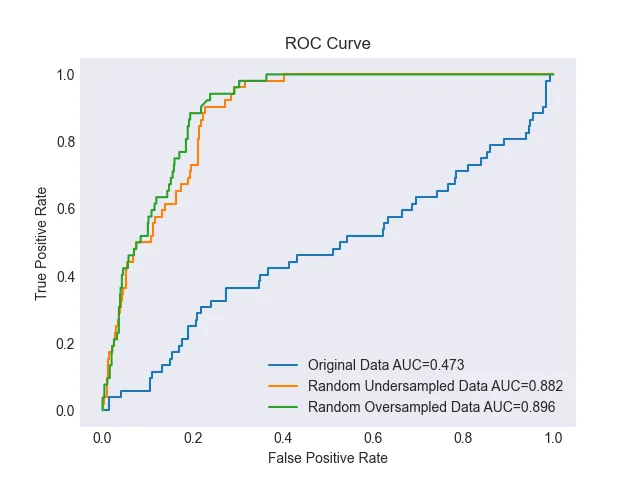

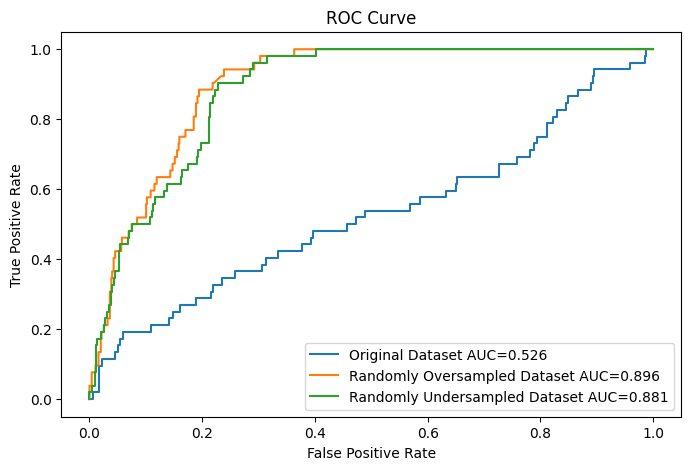

In [15]:
from sklearn.svm import SVC
from sklearn import metrics
import matplotlib.pyplot as plt

# Helper function for plotting ROC
def plot_roc(ax, X_train, y_train, X_test, y_test, title):
    clf = SVC(kernel='linear',probability=True)
    clf.fit(X_train, y_train)
    y_test_pred = clf.predict_proba(X_test)[:,1]
    fpr, tpr, thresh = metrics.roc_curve(y_test, y_test_pred)
    auc = metrics.roc_auc_score(y_test, y_test_pred)
    ax.plot(fpr,tpr,label=f"{title} AUC={auc:.3f}")

    ax.set_title('ROC Curve')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc=0)

# Plot all ROC into one graph
fig,ax = plt.subplots(1,1,figsize=(8,5))
plot_roc(ax, X_train_pca, y_train, X_test_pca, y_test, 'Original Dataset')
plot_roc(ax, X_train_ros, y_train_ros, X_test_pca, y_test, 'Randomly Oversampled Dataset')
plot_roc(ax, X_train_rus, y_train_rus, X_test_pca, y_test, 'Randomly Undersampled Dataset')

The SVC trained on the original data performed poorly. It did worse than if we were to randomly guess the output.

The randomly oversampled dataset outperformed the under-sampled dataset. One possible reason is that there is a loss of information from removing data points from the undersampling procedure. Conversely, no information is lost from oversampling the data.

**Strategy 3. Oversampling with SMOTE**

SMOTE is a method of oversampling. Intuitively, SMOTE creates synthetic data points by interpolating between the minority data points that are close by to one another.

Here’s how SMOTE works (simplified).

1. Randomly select some data points in the minority class.

2. For every selected point, identify its k nearest neighbour(s).

3. For every neighbor, add a new point somewhere between the data point and the neighbor.

4. Repeat steps 2 to 4 until sufficient synthetic data points are created.

In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import LinearSVC

# Perform random sampling
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

# Train linear SVC
clf_smote = SVC(kernel='linear',probability=True)
clf_smote.fit(X_train_smote, y_train_smote)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


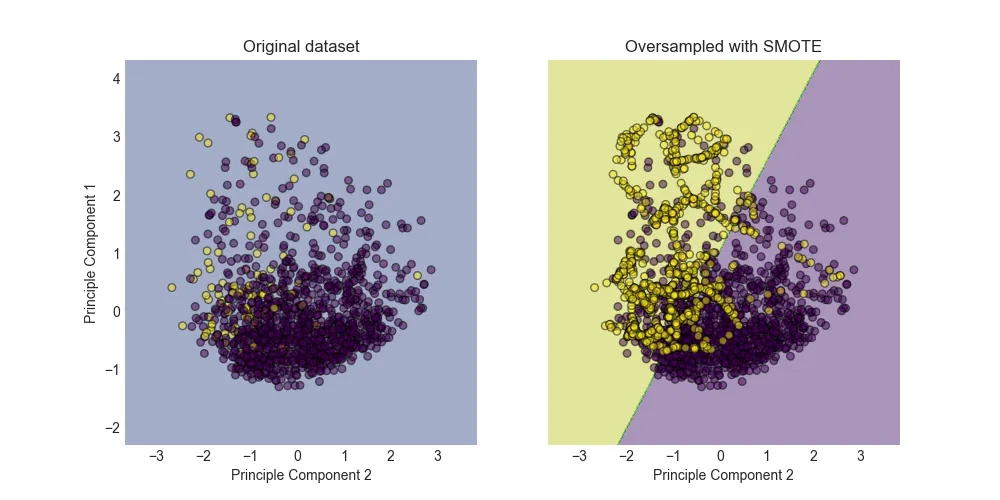

**Strategy 4. Oversampling with ADASYN (+ How it’s different from SMOTE)**

ADASYN is a cousin of SMOTE: both SMOTE and ADASYN generate new samples by interpolation.

But there’s on critical difference. ADASYN generates samples next to the original samples that are wrongly classified by a KNN classifier. Conversely, SMOTE differentiates between samples that are correctly or wrongly classified by the KNN classifier.

In [17]:
from imblearn.over_sampling import ADASYN

# Perform random sampling
adasyn = ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_pca, y_train)

# Train linear SVC
from sklearn.svm import SVC
clf_adasyn = SVC(kernel='linear',probability=True)
clf_adasyn.fit(X_train_adasyn, y_train_adasyn)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


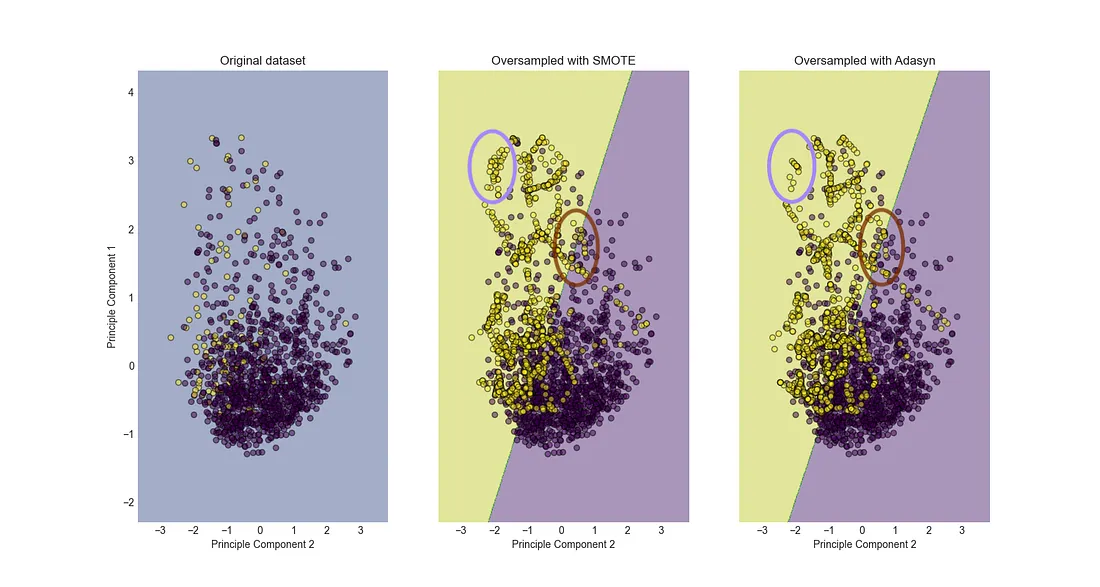

Here are a few observations.

First, both over-sampling approaches cause more synthetic data points to be created in between original data points. That’s because both SMOTE and ADASYN use interpolation to create new data points.

Second, comparing SMOTE and ADASYN, we notice ADASYN creates data points for minority (yellow) points near the majority (purple) data points.

Comparing the regions circled in blue above, ADASYN created fewer yellow data points in regions with only a few purple data points.
Comparing the regions circled in brown above, ADASYN created more yellow data points in regions with more purple data points.
Let’s compare the ROC of all over-sampling methods we have described so far. In this example, they perform equally well.

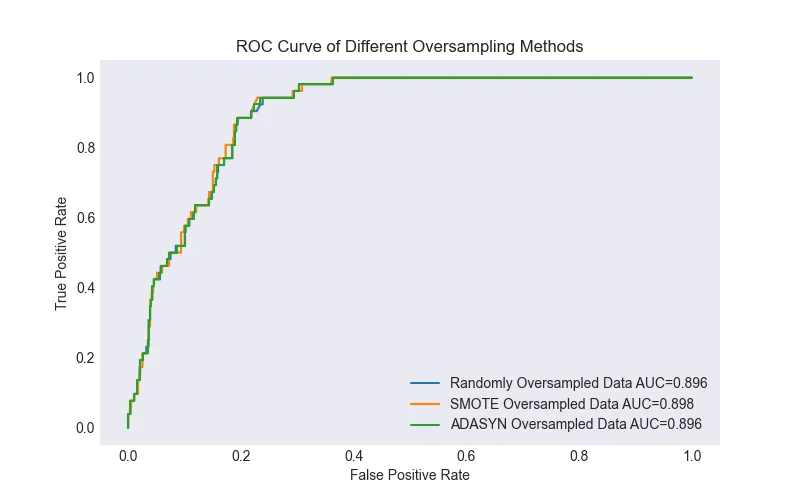

**Strategy 5. Under-sampling with Tomek Links**

A tomek link is a pair of points that are very close to one another but are of different classes. 

To under-sample with Tomek Links, we will identify all Tomek Links in the data set. For each pair of data point in the Tomek Link, we will remove the majority class.

Here’s an animation that illustrates undersampling with Tomek Link.

We will apply Tomek Link undersampling to our dataset.

In [18]:
from imblearn.under_sampling import TomekLinks
from sklearn.svm import LinearSVC

# Perform Tomek Link undersampling
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_pca, y_train)

# Train linear SVC
clf_tomek = SVC(kernel='linear',probability=True)
clf_tomek.fit(X_train_tomek, y_train_tomek)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


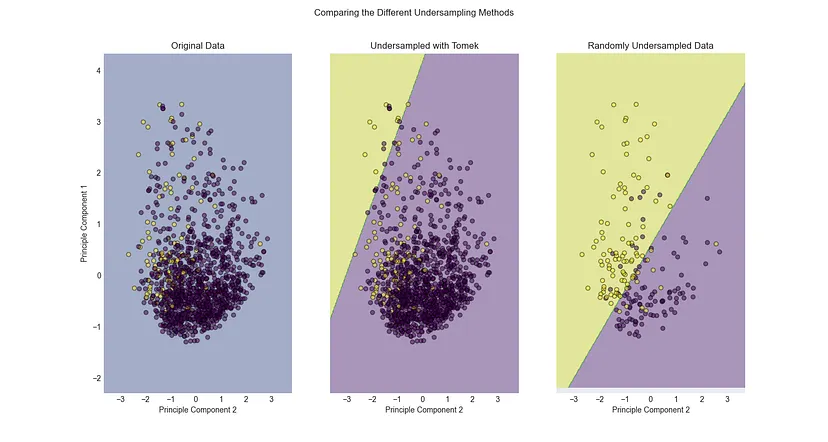

In our particular dataset, removing Tomek Link did little to ease the class imbalance. This is because there are limited number of Tomek Links in the dataaset.

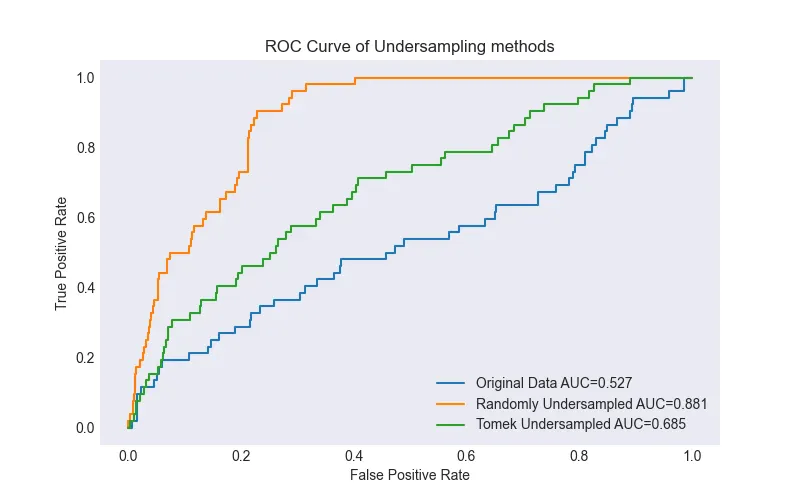

**Strategy 6. SMOTEK: Oversample with SMOTE, then Undersample with Tomek Links**

SMOTE-TOMEK is a technique that combines oversampling (SMOTE) with undersampling (with Tomek Links).

In [19]:
from imblearn.combine import SMOTETomek
from sklearn.svm import LinearSVC

# Perform random sampling
smotetomek = SMOTETomek(random_state=0)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train_pca, y_train)

# Plot linear SVC
clf_smotetomek = SVC(kernel='linear',probability=True)
clf_smotetomek.fit(X_train_smotetomek, y_train_smotetomek)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


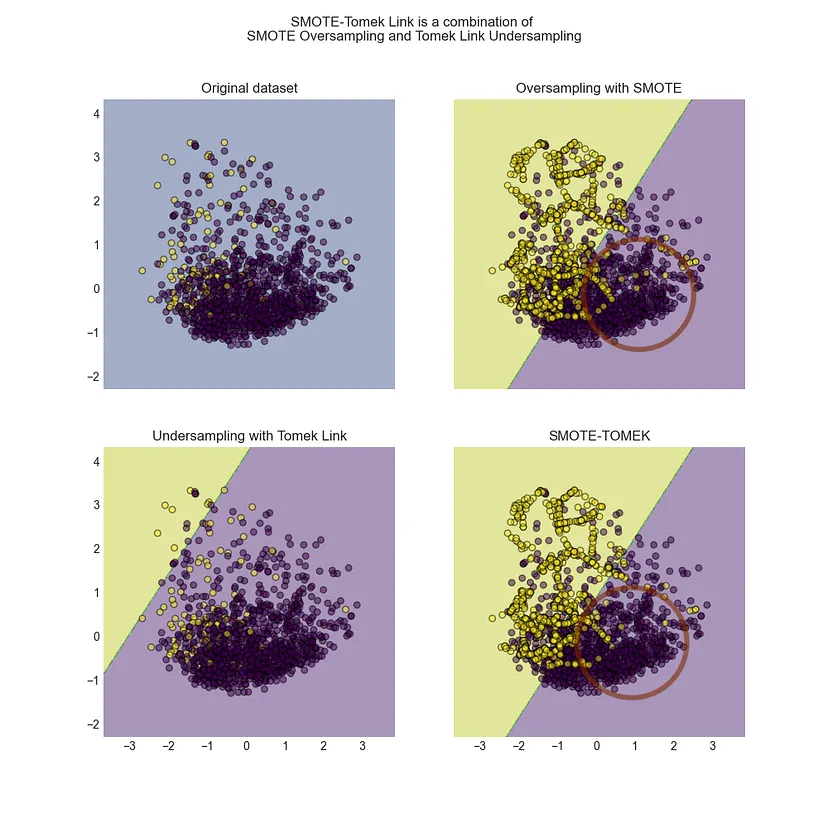

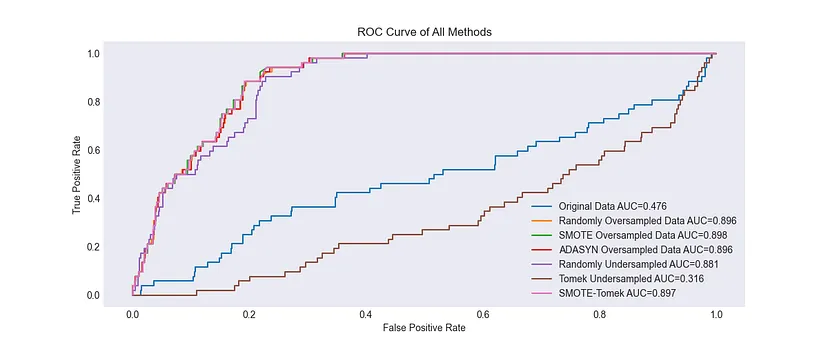